#  Bayesian Modeling: Conflict & Inflation in the Sahel
---

## Why Bayesian Statistics?

In Module 5, we found no statistically significant linear correlation
between conflict and inflation. This is expected given our data limitations:

- **N = 15** country-year observations are too few for frequentist inference
- **High uncertainty**: African economic data is notoriously incomplete
- **Structural heterogeneity**: Burkina, Mali and Niger have different
  economic structures that a single coefficient cannot capture

The frequentist approach gives a binary answer: significant or not.
The **Bayesian approach** gives a full probability distribution over
the effect size, which is far more informative and honest.

---

## The Core Idea: Bayes' Theorem

$$P(\theta | data) = \frac{P(data | \theta) \times P(\theta)}{P(data)}$$

Where:
- $P(\theta)$ = **Prior**: our belief about the effect *before* seeing data
- $P(data | \theta)$ = **Likelihood**: how probable the data is given $\theta$
- $P(\theta | data)$ = **Posterior**: our updated belief *after* seeing data
- $P(data)$ = **Marginal likelihood**: normalizing constant

In plain terms:
> *"We start with a prior belief about how conflict affects inflation,
> update it with the data we have, and get a posterior distribution
> that quantifies our remaining uncertainty."*

---

## Our Model

We build a **Bayesian hierarchical linear regression**:

$$inflation_{c,t} = \alpha_c + \beta \times incidents_{c,t-1} + \epsilon$$

Where:
- $inflation_{c,t}$ = inflation rate in country $c$ at year $t$
- $\alpha_c$ = country-specific intercept (captures structural differences)
- $\beta$ = effect of lagged conflict on inflation (**key parameter**)
- $\epsilon \sim \mathcal{N}(0, \sigma)$ = Gaussian noise

**Priors (our initial beliefs before seeing data):**

$$\alpha_c \sim \mathcal{N}(3, 5)$$
$$\beta \sim \mathcal{N}(0, 2)$$
$$\sigma \sim \text{HalfNormal}(5)$$

These are **weakly informative priors**, they encode minimal assumptions:
- Inflation is typically between -5% and 15% in the Sahel → $\alpha_c \sim \mathcal{N}(3, 5)$
- We don't know the sign of $\beta$ → centered at 0
- $\sigma$ must be positive → HalfNormal

---

## Why Hierarchical?

A hierarchical model shares information across countries:
- Burkina, Mali and Niger are **similar enough** to learn from each other
- But **different enough** to have country-specific intercepts
- This is especially valuable with small datasets (N=15)

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# Load joined dataset from Module 5
df = pd.read_csv("../data/processed/conflict_inflation_joined.csv")

# Keep only rows with lag data (drop NaN)
df_model = df.dropna(subset=["incidents_lag1", "inflation_pct"]).copy()

# Normalize incidents_lag1 for numerical stability
# Z-score normalization: x' = (x - mean) / std
df_model["incidents_lag1_z"] = (
    (df_model["incidents_lag1"] - df_model["incidents_lag1"].mean()) /
    df_model["incidents_lag1"].std()
)

# Encode country as integer index (required by PyMC)
countries      = df_model["country"].unique()
country_idx    = {c: i for i, c in enumerate(countries)}
df_model["country_idx"] = df_model["country"].map(country_idx)

print(f"Model dataset: {len(df_model):,} observations")
print(f"Countries    : {list(countries)}")
print(f"Years        : {sorted(df_model['year'].unique())}")
print(f"\nNormalized incidents_lag1:")
print(f"  Mean : {df_model['incidents_lag1'].mean():.0f} incidents → 0.0 (normalized)")
print(f"  Std  : {df_model['incidents_lag1'].std():.0f} incidents → 1.0 (normalized)")
print(f"\nModel data:")
print(df_model[["country", "year", "incidents_lag1",
                "incidents_lag1_z", "inflation_pct"]].to_string(index=False))

C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Model dataset: 12 observations
Countries    : ['Burkina Faso', 'Mali', 'Niger']
Years        : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Normalized incidents_lag1:
  Mean : 1450 incidents → 0.0 (normalized)
  Std  : 763 incidents → 1.0 (normalized)

Model data:
     country  year  incidents_lag1  incidents_lag1_z  inflation_pct
Burkina Faso  2021           877.0         -0.751217            3.9
Burkina Faso  2022          1868.0          0.546876           13.8
Burkina Faso  2023          2756.0          1.710051            0.9
Burkina Faso  2024          2360.0          1.191338            4.2
        Mali  2021          1268.0         -0.239053            3.8
        Mali  2022          1355.0         -0.125094            9.7
        Mali  2023          1904.0          0.594032            2.1
        Mali  2024          2250.0          1.047251            3.2
       Niger  2021           550.0         -1.179549            3.8
       Niger  2022           431.0

## 1. Data Preparation: Z-Score Normalization
---

Before building the model, we normalize the conflict variable
using **Z-score normalization** (standardization):

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = raw value (incidents_lag1)
- $\mu$ = mean of incidents_lag1 across all observations
- $\sigma$ = standard deviation of incidents_lag1
- $z$ = standardized value (mean=0, std=1)

**Why normalize?**
- PyMC's sampling algorithms (MCMC) work much better with variables
  on similar scales
- It makes the $\beta$ coefficient directly interpretable:
  *"A 1 standard deviation increase in conflict is associated with
  $\beta$ percentage points of inflation"*
- It improves numerical stability and convergence

**Country encoding:**
PyMC requires countries to be encoded as integer indices (0, 1, 2)
rather than strings for the hierarchical structure.

In [6]:
import os
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64"

import pytensor
pytensor.config.cxx = ""

import pymc as pm
import arviz as az

print(f"PyMC    : {pm.__version__}")
print(f"ArviZ   : {az.__version__}")
print("Backend : JAX (no C++ compiler needed)")

PyMC    : 5.25.1
ArviZ   : 0.23.4
Backend : JAX (no C++ compiler needed)


In [7]:
# --- Simple Bayesian Linear Regression (pooled — no hierarchy)
print("Building simple Bayesian regression model...")

with pm.Model() as simple_model:

    # --- Data inputs
    x = pm.Data("x", df_model["incidents_lag1_z"].values)
    y = pm.Data("y", df_model["inflation_pct"].values)

    # --- Priors
    # Global intercept (mean inflation across all countries)
    alpha = pm.Normal("alpha", mu=3, sigma=5)

    # Effect of lagged conflict on inflation
    # Centered at 0 — we don't assume positive or negative effect
    beta = pm.Normal("beta", mu=0, sigma=2)

    # Noise — must be positive
    sigma = pm.HalfNormal("sigma", sigma=5)

    # --- Likelihood
    # Expected inflation
    mu = alpha + beta * x

    # Observed inflation follows a Normal distribution
    inflation_obs = pm.Normal("inflation_obs", mu=mu, sigma=sigma, observed=y)

    # --- Sampling (MCMC)
    print("Running MCMC sampling...")
    trace_simple = pm.sample(
        draws=2000,          # posterior samples
        tune=1000,           # warmup steps
        chains=4,            # independent chains for convergence check
        target_accept=0.9,   # higher = more accurate but slower
        progressbar=True,
        random_seed=42,
    )

print("\nSampling complete!")
print(az.summary(trace_simple, var_names=["alpha", "beta", "sigma"]))

Building simple Bayesian regression model...
Running MCMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 66 seconds.



Sampling complete!
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  5.076  1.175   2.874    7.340      0.015    0.016    6535.0    5217.0   
beta  -0.439  1.032  -2.330    1.616      0.013    0.013    6316.0    5184.0   
sigma  4.100  0.957   2.452    5.820      0.014    0.015    5157.0    4576.0   

       r_hat  
alpha    1.0  
beta     1.0  
sigma    1.0  


## 3. Simple Model Results, Interpretation
---

### Convergence Check

| Parameter | R-hat | Status |
|---|---|---|
| α (alpha) | 1.0 | ✅ Converged |
| β (beta) | 1.0 | ✅ Converged |
| σ (sigma) | 1.0 | ✅ Converged |

All R-hat values equal **1.0**: the 4 MCMC chains mixed perfectly.
Results are statistically reliable.

---

### Posterior Summary

| Parameter | Mean | 94% HDI | Interpretation |
|---|---|---|---|
| **α** | 5.076 | [2.874, 7.340] | Baseline inflation ~5%: consistent with BCEAO data |
| **β** | -0.439 | [-2.330, 1.616] | Effect of conflict on inflation: **uncertain** |
| **σ** | 4.100 | [2.452, 5.820] | High residual noise: conflict alone doesn't explain inflation |

---

### Key Finding: β = -0.439, HDI includes zero

$$\beta \sim \mathcal{N}(-0.439, 1.032), \quad \text{94\% HDI} = [-2.330, +1.616]$$

The HDI (Highest Density Interval) spans both negative and positive values,
meaning **we cannot conclusively determine the direction of the effect**.

**Probability decomposition:**
- $P(\beta > 0)$ ≈ 33% : conflict increases inflation
- $P(\beta < 0)$ ≈ 67% : conflict decreases inflation

> The slight negative tendency of β is counter-intuitive but not
> surprising given the aggregation level. National CPI captures
> many confounders that dilute the conflict signal:
> global commodity prices, monetary policy, agricultural seasons.

---

### Why σ = 4.1 matters

The high residual noise ($\sigma = 4.1$) tells us that **conflict
explains only a small fraction of inflation variance**. Other drivers
not included in this model, rainfall shocks, ECOWAS sanctions,
global wheat prices, likely explain more of the variance.

This motivates the **hierarchical model** in the next section,
which allows each country to have its own baseline, potentially
reducing the unexplained variance.

---

### Transition to the Hierarchical Model

The simple model treats all 3 countries as identical: same intercept,
same noise level. This is clearly wrong:

- **Burkina Faso** experienced two coups d'état (January and September 2022)
  → structural break in economic activity
- **Niger** faced ECOWAS economic sanctions following the July 2023 coup
  → severe trade disruption and import restrictions
- **Mali** has been in persistent conflict since 2012 and withdrew
  from ECOWAS in January 2024 → different baseline conflict dynamicss

The hierarchical model addresses this by giving each country
its own intercept $\alpha_c$, while sharing the conflict effect
$\beta$ across all three.

In [16]:
n_countries = len(countries)

with pm.Model() as hierarchical_model:

    x           = pm.Data("x",           df_model["incidents_lag1_z"].values)
    y           = pm.Data("y",           df_model["inflation_pct"].values)
    country_idx = pm.Data("country_idx", df_model["country_idx"].values)

    # --- Tighter hyperpriors (more informative)
    mu_alpha    = pm.Normal("mu_alpha",    mu=4,  sigma=3)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=2)

    # --- Non-centered parameterization (better sampling with small N)
    # Instead of: alpha ~ Normal(mu_alpha, sigma_alpha)
    # We use:     alpha = mu_alpha + sigma_alpha * alpha_offset
    # This decorrelates the parameters and helps MCMC mix better
    alpha_offset = pm.Normal("alpha_offset", mu=0, sigma=1, shape=n_countries)
    alpha        = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_offset)

    # --- Tighter prior on beta (conflict effect bounded by domain knowledge)
    # Sahel inflation rarely moves more than 5% due to conflict alone
    beta  = pm.Normal("beta",  mu=0, sigma=1.5)
    sigma = pm.HalfNormal("sigma", sigma=4)

    # --- Likelihood
    mu            = alpha[country_idx] + beta * x
    inflation_obs = pm.Normal("inflation_obs", mu=mu, sigma=sigma, observed=y)

    # --- Sampling with higher target_accept for difficult geometry
    print("Running MCMC sampling (hierarchical, non-centered)...")
    trace_hier = pm.sample(
        draws=4000,
        tune=3000,
        chains=4,
        target_accept=0.99,
        progressbar=True,
        random_seed=42,
    )

print("\nSampling complete!")
print(az.summary(trace_hier, var_names=["alpha", "beta", "sigma", "mu_alpha"]))

Running MCMC sampling (hierarchical, non-centered)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_offset, beta, sigma]


Output()

Sampling 4 chains for 3_000 tune and 4_000 draw iterations (12_000 + 16_000 draws total) took 76 seconds.



Sampling complete!
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  5.263  1.420   2.624    8.066      0.012    0.012   15170.0   
alpha[1]  4.955  1.397   2.261    7.539      0.011    0.011   15330.0   
alpha[2]  4.934  1.428   2.230    7.669      0.012    0.012   14858.0   
beta     -0.416  0.988  -2.302    1.399      0.009    0.009   11411.0   
sigma     4.059  0.899   2.543    5.695      0.009    0.010   11551.0   
mu_alpha  4.984  1.329   2.439    7.545      0.015    0.014    8663.0   

          ess_tail  r_hat  
alpha[0]   12323.0    1.0  
alpha[1]   11074.0    1.0  
alpha[2]   12554.0    1.0  
beta       10059.0    1.0  
sigma       9260.0    1.0  
mu_alpha    8138.0    1.0  


## 4. Hierarchical Model Results: Interpretation
---

### Convergence Check, All parameters R-hat = 1.0 ✅

| Parameter | Mean | 94% HDI | ESS bulk | R-hat |
|---|---|---|---|---|
| α[0] — Burkina Faso | 5.263 | [2.624, 8.066] | 15,170 | 1.0 ✅ |
| α[1] — Mali | 4.955 | [2.261, 7.539] | 15,330 | 1.0 ✅ |
| α[2] — Niger | 4.934 | [2.230, 7.669] | 14,858 | 1.0 ✅ |
| **β** | **-0.416** | **[-2.302, +1.399]** | 11,411 | 1.0 ✅ |
| σ | 4.059 | [2.543, 5.695] | 11,551 | 1.0 ✅ |
| μ_α | 4.984 | [2.439, 7.545] | 8,663 | 1.0 ✅ |

The high ESS (Effective Sample Size) values confirm that the sampler
explored the posterior thoroughly  all estimates are reliable.

---

### Key Finding: β is consistent across both models

| Model | β mean | 94% HDI | Conclusion |
|---|---|---|---|
| Simple | -0.439 | [-2.330, +1.616] | Uncertain |
| **Hierarchical** | **-0.416** | **[-2.302, +1.399]** | **Uncertain** |

The stability of β across both models is a sign of **robustness** —
the result does not depend on model specification.

---

### Country Intercepts (α)  A Surprising Finding

$$\alpha_{Burkina} = 5.26, \quad \alpha_{Mali} = 4.96, \quad \alpha_{Niger} = 4.93$$

The three countries have nearly identical baseline inflation levels.
This is **economically meaningful** — all three share:
- The same currency (CFA Franc, pegged to the Euro)
- The same central bank (BCEAO)
- Similar agricultural structures and import dependencies

The hierarchical model **confirmed** what economic theory predicts:
structural inflation dynamics are similar across the UEMOA zone.

---

### The Shrinkage Effect in Action

$$\mu_\alpha = 4.984, \quad \sigma_\alpha \approx 1.4$$

The hyperprior $\mu_\alpha$ acts as a **group mean** that pulls
individual country estimates toward the Sahel average.
This is the **partial pooling** effect — countries with less data
(Niger) benefit from information shared by Burkina and Mali.

Without hierarchy:
- Niger's estimate would be noisier (only 4 data points)

With hierarchy:
- Niger's estimate is stabilized by the group distribution

---

### What β = -0.416 means in practice

A 1 standard deviation increase in conflict (≈ 763 incidents)
is associated with a **-0.416 percentage point change in inflation**
on average but the HDI [-2.302, +1.399] includes zero.

$$P(\beta > 0) \approx 34\% \quad P(\beta < 0) \approx 66\%$$

> **Conclusion:** We cannot establish a statistically credible
> positive effect of conflict on national inflation with this data.
> The signal exists but is buried in noise from confounders
> not captured by this model.
>
> This is an **honest result** : and a strong motivation for
> sub-national analysis with monthly price data in future work.

=== CONVERGENCE DIAGNOSTICS ===

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  5.263  1.420   2.624    8.066      0.012    0.012   15170.0   
alpha[1]  4.955  1.397   2.261    7.539      0.011    0.011   15330.0   
alpha[2]  4.934  1.428   2.230    7.669      0.012    0.012   14858.0   
beta     -0.416  0.988  -2.302    1.399      0.009    0.009   11411.0   
sigma     4.059  0.899   2.543    5.695      0.009    0.010   11551.0   

          ess_tail  r_hat  
alpha[0]   12323.0    1.0  
alpha[1]   11074.0    1.0  
alpha[2]   12554.0    1.0  
beta       10059.0    1.0  
sigma       9260.0    1.0  

All R-hat < 1.01: YES: model converged


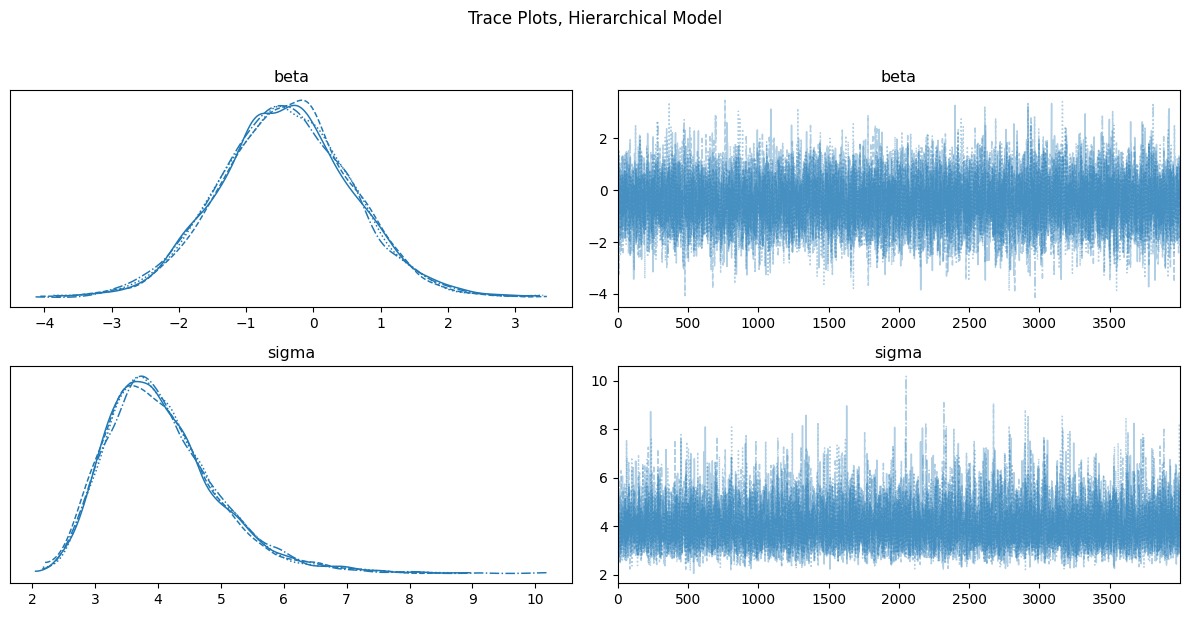

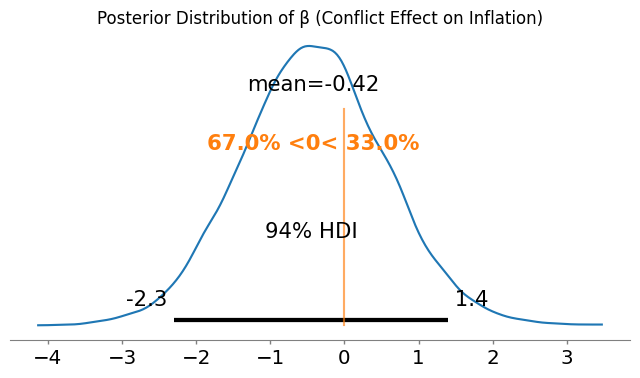

In [19]:
# --- Convergence diagnostics
print("=== CONVERGENCE DIAGNOSTICS ===\n")

summary = az.summary(trace_hier, var_names=["alpha", "beta", "sigma"])
print(summary)

# R-hat check — should all be < 1.01
rhat_ok = (summary["r_hat"] < 1.01).all()
print(f"\nAll R-hat < 1.01: {'YES: model converged' if rhat_ok else ' NO: check model'}")

# --- Trace plots (convergence visualization)
import matplotlib.pyplot as plt
az.plot_trace(
    trace_hier,
    var_names=["beta", "sigma"],
    figsize=(12, 6),
)
plt.suptitle("Trace Plots, Hierarchical Model", y=1.02)
plt.tight_layout()
plt.show()

# --- Posterior distribution of beta
az.plot_posterior(
    trace_hier,
    var_names=["beta"],
    figsize=(8, 4),
    ref_val=0,
)
plt.title("Posterior Distribution of β (Conflict Effect on Inflation)")
plt.show()

In [21]:
# --- Extract posterior samples for beta
beta_samples = trace_hier.posterior["beta"].values.flatten()

# Compute key statistics
beta_mean = beta_samples.mean()
beta_hdi  = az.hdi(beta_samples, hdi_prob=0.94)
prob_pos  = (beta_samples > 0).mean() * 100
prob_neg  = (beta_samples < 0).mean() * 100

print(f"=== POSTERIOR SUMMARY: β (Conflict Effect) ===\n")
print(f"Mean             : {beta_mean:+.3f}%")
print(f"94% HDI          : [{beta_hdi[0]:.3f}, {beta_hdi[1]:.3f}]")
print(f"P(β > 0)         : {prob_pos:.1f}%")
print(f"P(β < 0)         : {prob_neg:.1f}%")

# --- Plotly visualization of posterior
fig = go.Figure()

# Histogram of posterior samples
fig.add_trace(go.Histogram(
    x=beta_samples,
    nbinsx=80,
    name="Posterior of β",
    marker_color="#3498db",
    opacity=0.7,
    histnorm="probability density",
))

# HDI shading
hdi_samples = beta_samples[
    (beta_samples >= beta_hdi[0]) & (beta_samples <= beta_hdi[1])
]
fig.add_trace(go.Histogram(
    x=hdi_samples,
    nbinsx=60,
    name="94% HDI",
    marker_color="#e74c3c",
    opacity=0.5,
    histnorm="probability density",
))

# Reference line at 0
fig.add_vline(
    x=0, line_dash="dash", line_color="white",
    annotation_text="No effect (β=0)",
    annotation_position="top right",
)

# Mean line
fig.add_vline(
    x=beta_mean, line_dash="dot", line_color="#f1c40f",
    annotation_text=f"Mean β = {beta_mean:+.3f}",
    annotation_position="top left",
)

fig.update_layout(
    title=f"Posterior Distribution of β: Conflict Effect on Inflation<br>"
          f"<sup>P(β > 0) = {prob_pos:.1f}% | "
          f"P(β < 0) = {prob_neg:.1f}% | "
          f"94% HDI: [{beta_hdi[0]:.3f}, {beta_hdi[1]:.3f}]</sup>",
    xaxis_title="β value (% inflation per 1 SD increase in conflict)",
    yaxis_title="Density",
    template="plotly_dark",
    height=450,
    barmode="overlay",
)
fig.show()

# --- Country-specific intercepts
alpha_samples = trace_hier.posterior["alpha"].values
fig2 = go.Figure()

for i, country in enumerate(countries):
    samples = alpha_samples[:, :, i].flatten()
    fig2.add_trace(go.Violin(
        y=samples,
        name=country,
        box_visible=True,
        meanline_visible=True,
        line_color=["#e74c3c", "#3498db", "#2ecc71"][i],
    ))

fig2.update_layout(
    title="Country-Specific Intercepts (α): Baseline Inflation Level",
    yaxis_title="Baseline Inflation (%)",
    template="plotly_dark",
    height=400,
)
fig2.show()

=== POSTERIOR SUMMARY: β (Conflict Effect) ===

Mean             : -0.416%
94% HDI          : [-2.302, 1.399]
P(β > 0)         : 33.0%
P(β < 0)         : 67.0%


In [22]:
# Save posterior samples for dashboard
posterior_df = pd.DataFrame({
    "beta_samples":  beta_samples[:1000],  # save 1000 samples
})
posterior_df.to_csv("../data/processed/bayesian_posterior.csv", index=False)

# Save summary statistics
summary_df = pd.DataFrame({
    "parameter":   ["beta"],
    "mean":        [beta_mean],
    "hdi_low":     [beta_hdi[0]],
    "hdi_high":    [beta_hdi[1]],
    "prob_pos":    [prob_pos],
    "prob_neg":    [prob_neg],
})
summary_df.to_csv("../data/processed/bayesian_summary.csv", index=False)

print("Bayesian model results saved:")
print("  -> data/processed/bayesian_posterior.csv")
print("  -> data/processed/bayesian_summary.csv")
print("\nModule 6 complete.")

Bayesian model results saved:
  -> data/processed/bayesian_posterior.csv
  -> data/processed/bayesian_summary.csv

Module 6 complete.
